# LesionLocator plots - updated simulation suggestion from Ben

- [ ] Change in diameter vs. real segmentation volume
- [ ] Simulate data by selecting different amounts of tumours
- [ ] Stratify plot by disease site and/or ground truth volume

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [115]:
import pandas as pd
from damply import dirs
from pathlib import Path
from workflow.scripts.utils.metadata_ll import add_source_labels
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Load in aligned simulation data 
data_folder = 'AI_for_Onc_2026'
dataset = "CVPR_LesionLocator"

nnint_recist_path = dirs.RESULTS / data_folder / "nnInt_ll_sim_plotting_info_pts.csv"
nnint_recist_df = pd.read_csv(nnint_recist_path) 

In [6]:
# Get the stem of the parent directory for each image in the GT_t1_mask_path column
def get_sample_id(path):
    return Path(path).parent.stem

nnint_recist_df['sample_id'] = nnint_recist_df['GT_t1_mask_path'].apply(get_sample_id)

# Load in name mapping for the LesionLocator data to the included datasets
name_mapping_path = dirs.RAWDATA / "MultiSite" / dataset / "images/naming.csv"
name_mapping_df = pd.read_csv(name_mapping_path)

nnint_recist_lbl_df = add_source_labels(nnint_recist_df, name_mapping_df)

In [7]:
nnint_recist_lbl_df

,GT_t1_mask_path,GT_t2_mask_path,GT_t1_max_ax_diam,GT_t2_max_ax_diam,GT_t1_vox_vol,GT_t2_vox_vol,GT_perc_diam_change,GT_perc_vol_change,GT_RECIST_cat,GT_vol_RECIST_cat,...,t2_2D_DICE,t1_HD95,t2_HD95,t1_surface_distance,t2_surface_distance,RECIST_flip,vol_RECIST_flip,sample_id,source_id,source_dataset
0,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,27.320286,21.554459,8658.047756,2402.944639,-21.104564,-72.246115,SD,PR,...,0.891374,130.288971,139.316269,84.143150,90.694397,False,True,LesionLocator_0001,KiTS23_case_00000,KiTS
1,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,16.794400,23.507817,1539.160812,6084.534969,39.974141,295.315091,PD,PD,...,0.935231,2.332516,1.500000,0.649408,0.510535,False,False,LesionLocator_0002,KiTS23_case_00001,KiTS
2,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,22.152182,27.729809,2860.082405,4968.132879,25.178676,73.705935,PD,PD,...,0.938032,6.460171,1.597656,1.513036,0.565855,True,True,LesionLocator_0002,KiTS23_case_00001,KiTS
3,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,20.689309,23.486328,3961.866489,4129.555202,13.519152,4.232569,SD,SD,...,0.884956,6.579733,6.576172,0.707795,0.664469,False,False,LesionLocator_0003,KiTS23_case_00002,KiTS
4,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,46.262701,51.154926,37011.546692,52394.779686,10.574880,41.563335,SD,SD,...,0.965103,1.878906,1.662872,0.540459,0.501411,False,False,LesionLocator_0003,KiTS23_case_00002,KiTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5481,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,28.343867,24.005560,8648.831920,3332.267384,-15.305981,-61.471475,SD,SD,...,0.821648,5.055877,6.250000,0.802618,0.459654,False,False,LesionLocator_2595,NSCLC-Radiogenomics_R01-093,NSCLC-\nRadiogenomics
5482,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,27.674251,30.991673,3526.354063,10427.015622,11.987394,195.688279,SD,PD,...,0.931801,3.109928,1.898438,0.700811,0.629051,True,False,LesionLocator_2596,NSCLC-Radiogenomics_R01-094,NSCLC-\nRadiogenomics
5483,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,23.411444,29.851521,2263.641357,6857.299805,27.508242,202.932255,PD,PD,...,0.850136,4.490659,3.426830,0.543535,0.528775,False,False,LesionLocator_2597,NSCLC-Radiogenomics_R01-095,NSCLC-\nRadiogenomics
5484,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,32.040776,31.868872,6050.872803,11859.130859,-0.536517,95.990417,SD,PD,...,0.904555,5.120615,3.049878,0.487446,0.532241,False,False,LesionLocator_2598,NSCLC-Radiogenomics_R01-096,NSCLC-\nRadiogenomics


## Tumour volume distribution

Text(0, 0.5, 'Tumour Volume')

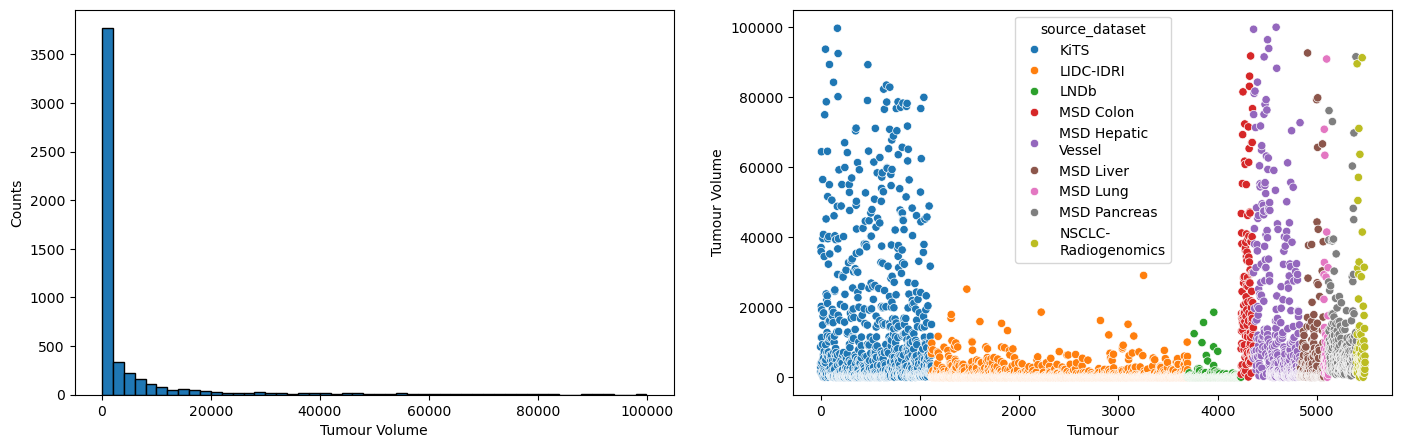

In [110]:
fig, ax = plt.subplots(figsize=(17,5), ncols=2, nrows=1)

plot_subset = nnint_recist_lbl_df[(nnint_recist_lbl_df['GT_t1_vox_vol'] < 100000)]

ax[0].hist(data=plot_subset, x='GT_t1_vox_vol', bins=50, edgecolor='black')
ax[0].set_xlabel('Tumour Volume')
ax[0].set_ylabel('Counts')

ax[1] = sns.scatterplot(x=plot_subset.index, y=plot_subset.GT_t1_vox_vol, hue=plot_subset.source_dataset)
ax[1].set_xlabel('Tumour')
ax[1].set_ylabel('Tumour Volume')

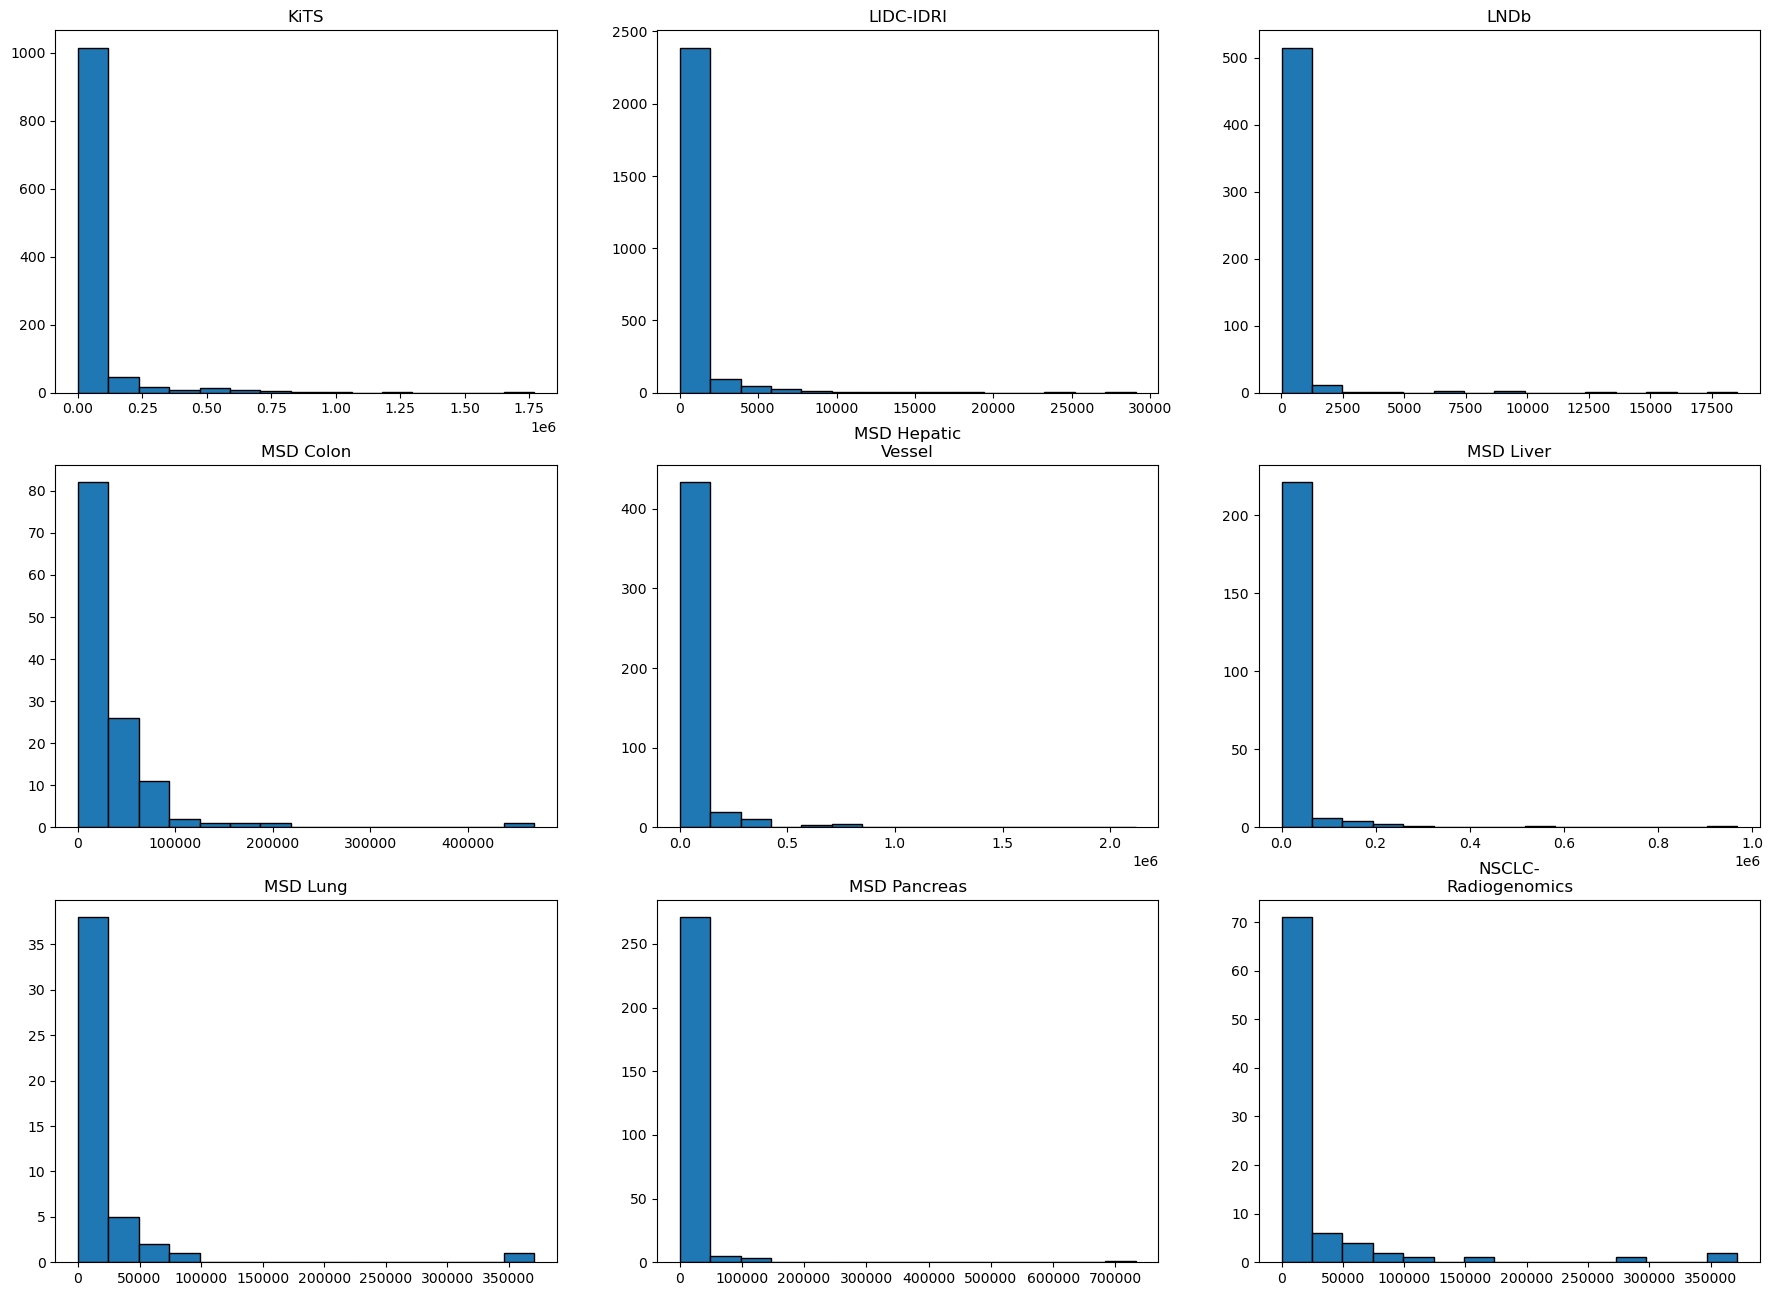

In [87]:
sources = nnint_recist_lbl_df['source_dataset'].unique()
num_sources = len(sources)

src_fig, src_ax = plt.subplots(nrows=3, ncols=3, figsize=(22,16))

for idx, src in enumerate(sources):
    src_subset = nnint_recist_lbl_df[nnint_recist_lbl_df['source_dataset']==src]
    ax = src_ax.flat[idx]
    ax.hist(data=src_subset, 
                          x='GT_t1_vox_vol', 
                          bins=15, 
                          edgecolor='black',)
    ax.set_title(src)

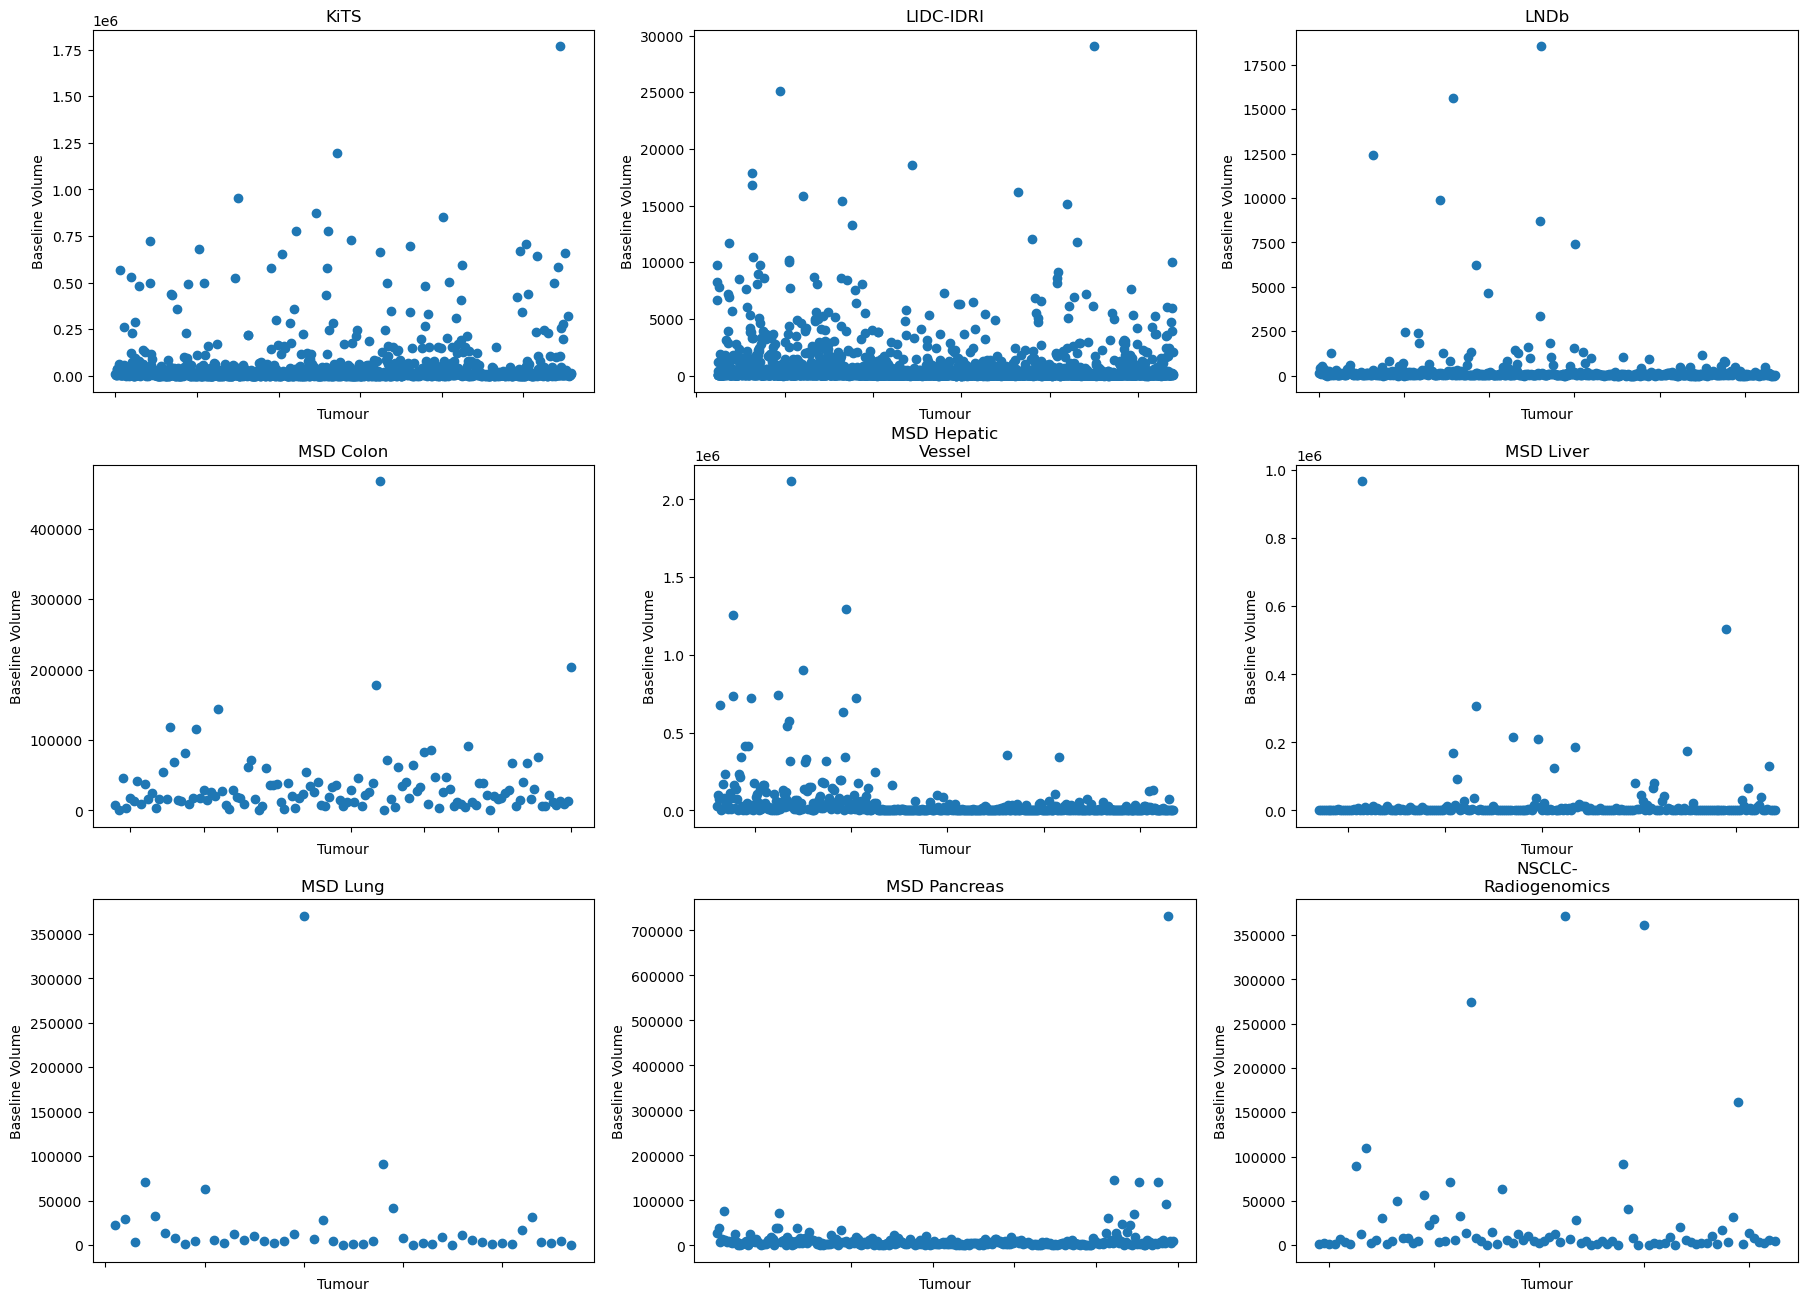

In [111]:
sources = nnint_recist_lbl_df['source_dataset'].unique()
num_sources = len(sources)

src_fig, src_ax = plt.subplots(nrows=3, ncols=3, figsize=(22,16))

for idx, src in enumerate(sources):
    src_subset = nnint_recist_lbl_df[nnint_recist_lbl_df['source_dataset']==src]
    # src_subset = src_subset.sort_values(by='GT_t1_vox_vol', ignore_index=True)
    ax = src_ax.flat[idx]
    ax.scatter(x= src_subset.index,
               y= src_subset['GT_t1_vox_vol'])
    ax.set_xticklabels([])
    ax.set_xlabel('Tumour')
    ax.set_ylabel('Baseline Volume')
    ax.set_title(src)

## Change in diameter vs. real segmentation volume

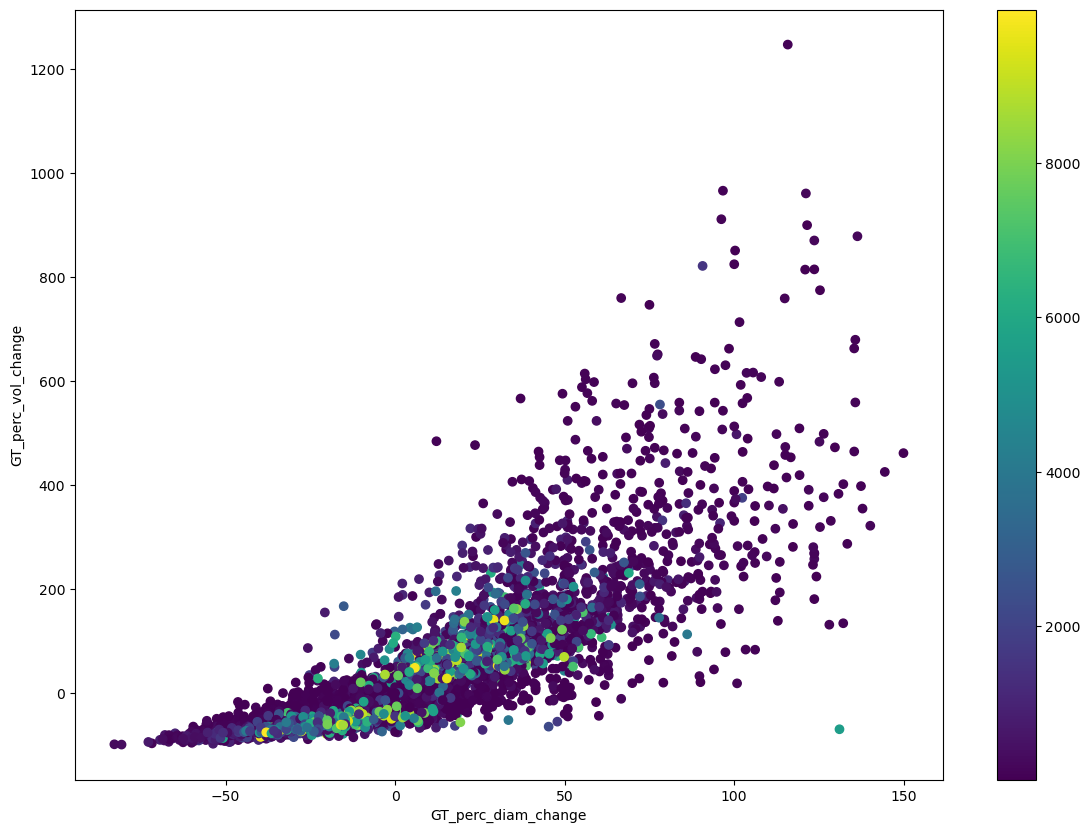

In [125]:
fig,axis = plt.subplots(figsize=(14,10), ncols=1, nrows=1)

plot_subset = nnint_recist_lbl_df[(nnint_recist_lbl_df['GT_perc_vol_change'] < 2000)&
                                  (nnint_recist_lbl_df['GT_perc_diam_change'] < 150)&
                                  (nnint_recist_lbl_df['GT_t1_vox_vol'] < 10000)]
x_axis = 'GT_perc_diam_change'
y_axis = 'GT_perc_vol_change'
color_by = 'GT_t1_vox_vol'

delta_scatter = axis.scatter(plot_subset[x_axis],
                            plot_subset[y_axis],
                            c = plot_subset[color_by],
                            )
axis.set_xlabel(x_axis)
axis.set_ylabel(y_axis)
cb = fig.colorbar(delta_scatter, ax=axis)

# diameters = np.arange(0, 50, 1).tolist()
# spheres = [4/3 * np.pi * (d/2) ** 3 for d in diameters]
# axis.plot(diameters, spheres)

In [124]:
spheres

[0.0,
 0.5235987755982988,
 4.1887902047863905,
 14.137166941154067,
 33.510321638291124,
 65.44984694978736,
 113.09733552923254,
 179.59438003021648,
 268.082573106329,
 381.7035074111598,
 523.5987755982989,
 696.9099703213358,
 904.7786842338603,
 1150.3465099894624,
 1436.7550402417319,
 1767.1458676442585,
 2144.660584850632,
 2572.440784514442,
 3053.6280592892786,
 3591.3640018287315,
 4188.790204786391,
 4849.048260815845,
 5575.279762570686,
 6370.6263027045015,
 7238.229473870882,
 8181.230868723419,
 9202.7720799157,
 10305.994700101315,
 11494.040321933855,
 12770.05053806691,
 14137.166941154068,
 15598.53112384892,
 17157.284678805056,
 18816.569198676065,
 20579.526276115535,
 22449.297503777063,
 24429.02447431423,
 26521.84878038063,
 28730.912014629852,
 31059.355769715487,
 33510.32163829113,
 36086.951213010354,
 38792.38608652676,
 41629.76785149395,
 44602.23810056549,
 47712.938426394976,
 50965.01042163601,
 54361.595678942176,
 57905.83579096706,
 61600.872350

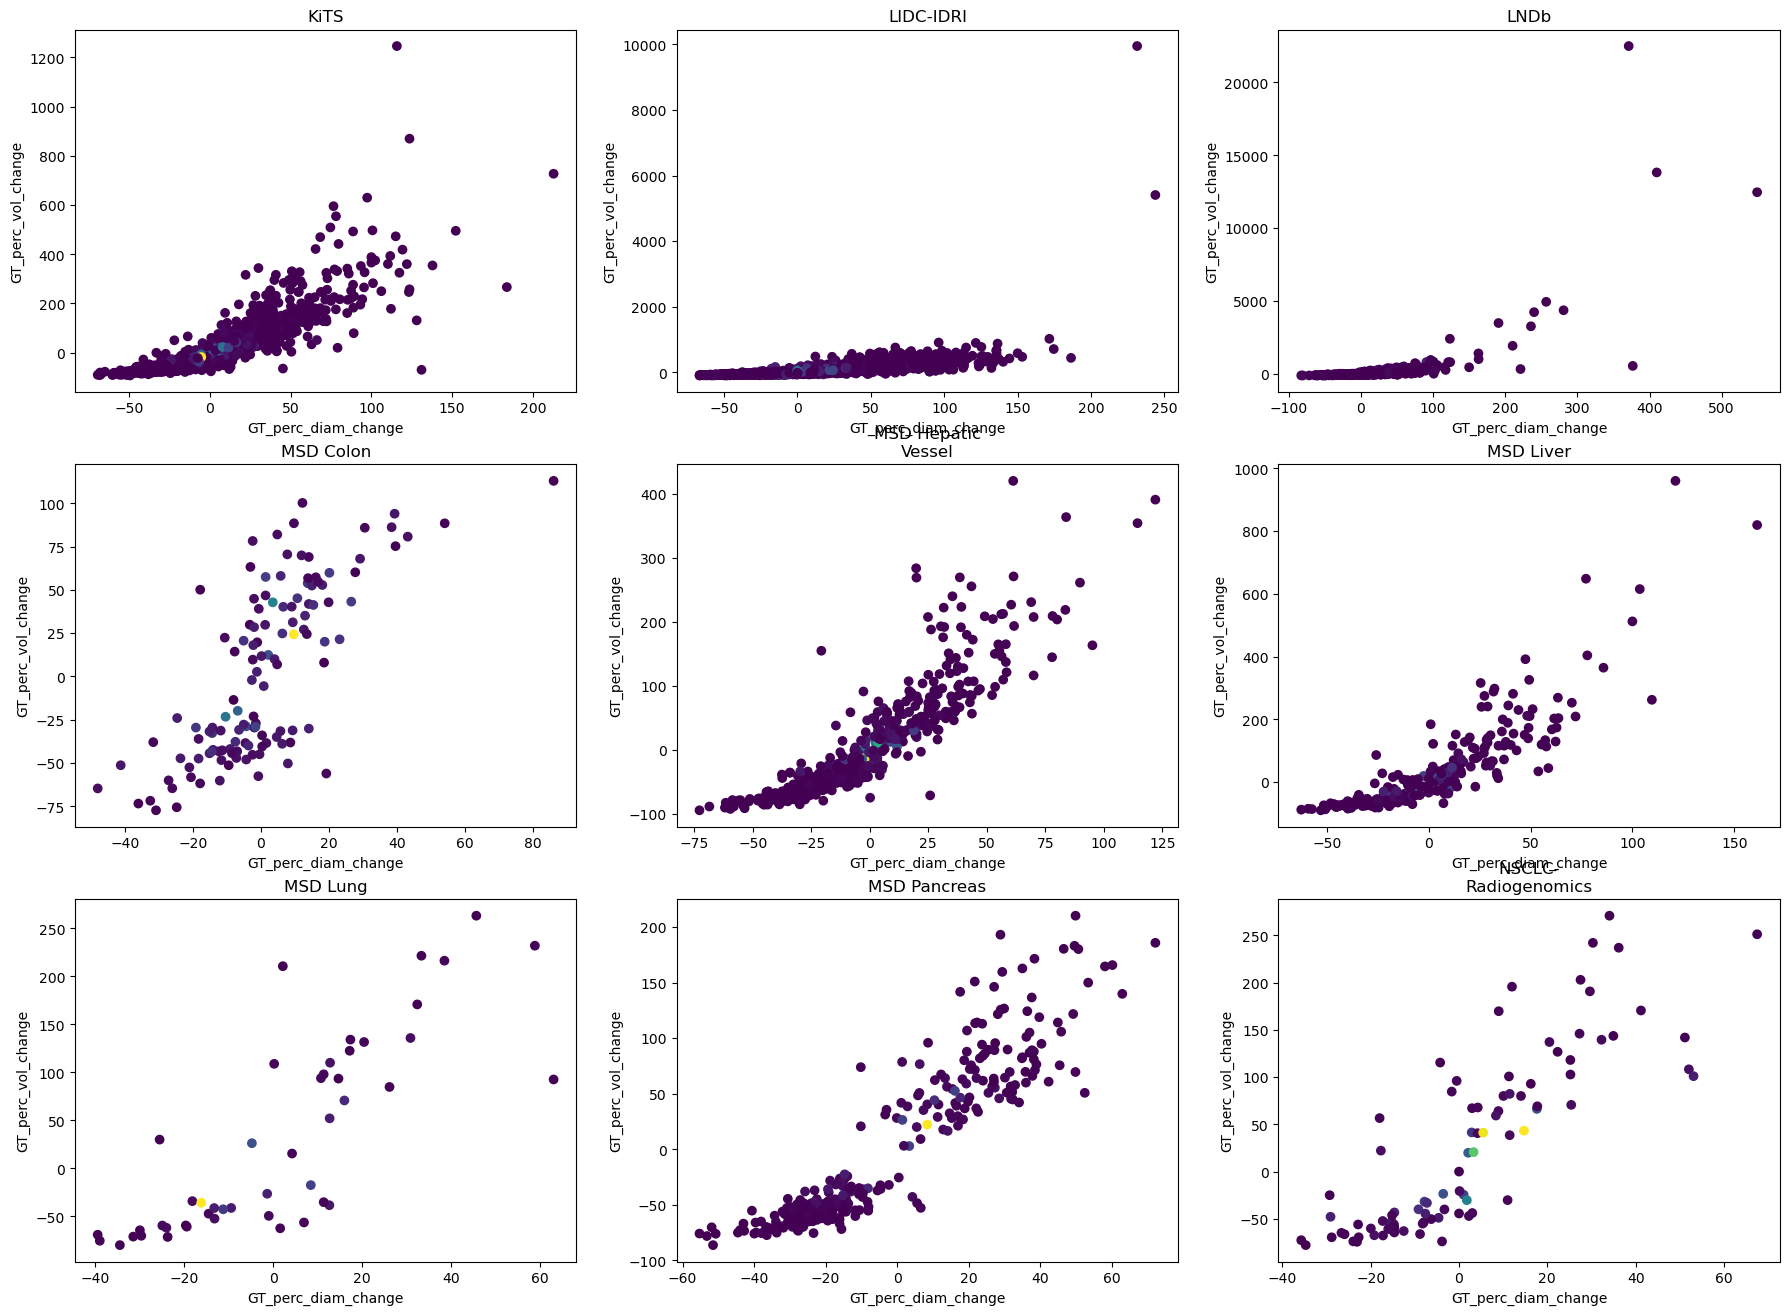

In [114]:
sources = nnint_recist_lbl_df['source_dataset'].unique()
num_sources = len(sources)

src_fig, src_ax = plt.subplots(nrows=3, ncols=3, figsize=(22,16))

x_axis = 'GT_perc_diam_change'
y_axis = 'GT_perc_vol_change'
color_by = 'GT_t1_vox_vol'

for idx, src in enumerate(sources):
    src_subset = nnint_recist_lbl_df[nnint_recist_lbl_df['source_dataset']==src]
    ax = src_ax.flat[idx]
    ax.scatter(src_subset[x_axis],
               src_subset[y_axis],
               c = src_subset[color_by],)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)
    ax.set_title(src)